## EDA - Análisis Exploratorio de Datos

---

### Proyecto: Asistente Inteligente para Seguridad Urbana

---

### Módulo 2


El presente análisis exploratorio de datos  tiene como objetivo comprender las características y patrones de la criminalidad en Costa Rica, utilizando los datos públicos del Organismo de Investigación Judicial (OIJ) disponibles en el portal de Transparencia.

Según el manual de usuario del OIJ, presente en el mismo portal, los datos provienen de las denuncias interpuestas directamente ante el OIJ y toman como referencia la fecha del hecho, no la fecha de la denuncia.

## Carga de librerias

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

### Período analizado
El análisis cubre el período comprendido entre 2023 y 2026, con un total de 143,663 registros de incidentes delictivos.

---

## Carga de datos

In [15]:
df = pd.read_html('../data/raw/Estadisticas.ods')[0]
print(df.shape)
df.head(3)

(142781, 12)


,Delito,SubDelito,Fecha,Hora,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2023-01-01,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,VENEZUELA,SAN JOSE,SAN JOSE,MERCED
1,ASALTO,ARMA BLANCA,2023-01-03,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,HOSPITAL
2,ASALTO,ARMA BLANCA,2023-01-03,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,LIMON,SIQUIRRES,SIQUIRRES


## Limpieza Inicial

In [16]:
#Convertir Fecha a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

#Limpiar la columna Hora (viene con formato HH:MM:SS)
df['Hora'] = df['Hora'].str.split(':').str[0].astype(int)

Información del Dataset

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142781 entries, 0 to 142780
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Delito        142781 non-null  object        
 1   SubDelito     142781 non-null  object        
 2   Fecha         142781 non-null  datetime64[ns]
 3   Hora          142781 non-null  int64         
 4   Victima       142781 non-null  object        
 5   SubVictima    142781 non-null  object        
 6   Edad          142781 non-null  object        
 7   Sexo          142781 non-null  object        
 8   Nacionalidad  142781 non-null  object        
 9   Provincia     142781 non-null  object        
 10  Canton        142781 non-null  object        
 11  Distrito      142781 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 13.1+ MB


## Estadísticas Basicas

In [18]:
print(f"Fecha más antigua: {df['Fecha'].min()}")
print(f"Fecha más reciente: {df['Fecha'].max()}")
print(f"Total de días: {df['Fecha'].nunique()}")
print(f"Rango de horas: {df['Hora'].min()} - {df['Hora'].max()}")

Fecha más antigua: 2023-01-01 00:00:00
Fecha más reciente: 2026-03-11 00:00:00
Total de días: 1166
Rango de horas: 0 - 21


### Ver valores nulos

In [19]:
print(df.isnull().sum())

Delito          0
SubDelito       0
Fecha           0
Hora            0
Victima         0
SubVictima      0
Edad            0
Sexo            0
Nacionalidad    0
Provincia       0
Canton          0
Distrito        0
dtype: int64


### Analisis de delito por tipo

---

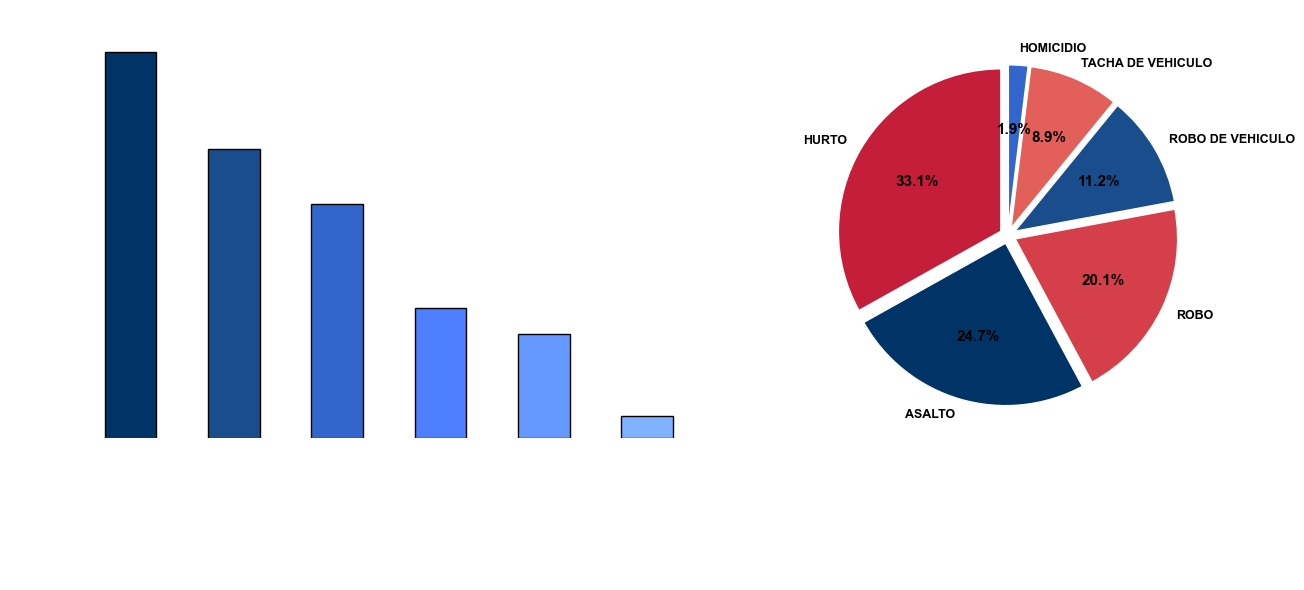

DISTRIBUCIÓN DE DELITOS
Delito
HURTO                47269
ASALTO               35320
ROBO                 28683
ROBO DE VEHICULO     15952
TACHA DE VEHICULO    12777
HOMICIDIO             2780
Name: count, dtype: int64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
axes[0].set_facecolor('white')
axes[1].set_facecolor('white')

top_delitos = df['Delito'].value_counts().head(10)

colores_azules = ['#003366', '#1a4d8c', '#3366cc', '#4d7fff', '#6699ff',
                  '#80b3ff', '#99ccff', '#b3e0ff', '#ccf0ff', '#e6f5ff']

top_delitos.plot(kind='bar', ax=axes[0], color=colores_azules, edgecolor='black', linewidth=1)
axes[0].set_title('Delitos Más Comunes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Delito', fontsize=12)
axes[0].set_ylabel('Número de Incidentes', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

top_delitos_percent = (top_delitos / len(df) * 100)

colores_pie = ['#C41E3A', '#003366', '#D43F4A', '#1a4d8c', '#E35F5A',
               '#3366cc', '#F2806A', '#4d7fff', '#FFA07A', '#6699ff']
wedges, texts, autotexts = axes[1].pie(top_delitos_percent,
                                        labels=top_delitos.index,
                                        autopct='%1.1f%%',
                                        explode=[0.05]*len(top_delitos),
                                        colors=colores_pie,
                                        textprops={'fontsize': 10},
                                        startangle=90)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_color('black')
    text.set_fontweight('bold')
    text.set_fontsize(9)

axes[1].set_title('Distribución Porcentual de Delitos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("DISTRIBUCIÓN DE DELITOS")
print(df['Delito'].value_counts())

El gráfico muestra que Hurto es el delito más frecuente con 47,564 incidentes. Le siguen Asalto (35,515 incidentes) y Robo (28,846 incidentes).

Según el manual del OIJ:
Hurto: Apoderarse de un bien sin utilizar fuerza en las cosas o violencia sobre las personas
Robo: Entrada ilícita ejerciendo fuerza sobre las cosas
Asalto: Desapoderamiento con violencia sobre las personas

Los delitos contra la propiedad (hurto, robo, asalto) representan más del 60% del total, lo que sugiere que las autoridades deberían enfocar recursos en la prevención de estos delitos.

### Análisis por hora del día

---

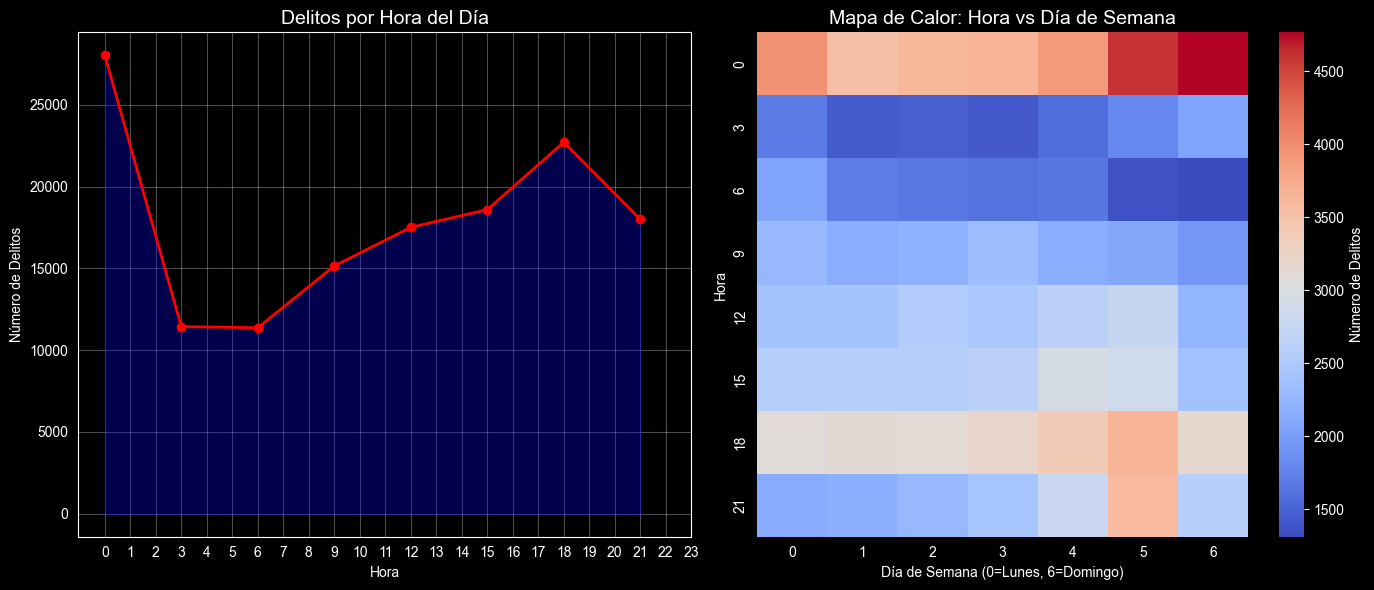

ESTADÍSTICAS POR HORA
Hora con más delitos: 0 (28,024 delitos)
Hora con menos delitos: 6 (11,369 delitos)
Promedio de delitos por hora: 17848


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

delitos_por_hora = df.groupby('Hora').size()

axes[0].plot(delitos_por_hora.index, delitos_por_hora.values,
             marker='o', linestyle='-', linewidth=2, markersize=6, color='red')

axes[0].fill_between(delitos_por_hora.index, delitos_por_hora.values,
                     alpha=0.3, color='blue')

axes[0].set_title('Delitos por Hora del Día', fontsize=14)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Número de Delitos')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))


df['DiaSemana'] = df['Fecha'].dt.dayofweek
tabla_hora_dia = pd.crosstab(df['Hora'], df['DiaSemana'])

sns.heatmap(tabla_hora_dia, ax=axes[1], cmap='coolwarm', annot=False, fmt='d',
            cbar_kws={'label': 'Número de Delitos'})

axes[1].set_title('Mapa de Calor: Hora vs Día de Semana', fontsize=14)
axes[1].set_xlabel('Día de Semana (0=Lunes, 6=Domingo)')
axes[1].set_ylabel('Hora')

plt.tight_layout()
plt.show()

print("ESTADÍSTICAS POR HORA")
print(f"Hora con más delitos: {delitos_por_hora.idxmax()} ({delitos_por_hora.max():,} delitos)")
print(f"Hora con menos delitos: {delitos_por_hora.idxmin()} ({delitos_por_hora.min():,} delitos)")
print(f"Promedio de delitos por hora: {delitos_por_hora.mean():.0f}")

Delitos por Hora del Día

La medianoche (hora 0) registra el mayor número de delitos con 28,188 incidentes, mientras que la hora 6 (6:00 AM) es la de menor actividad con 11,447 delitos.

Importante según el manual: Existe un rezago natural entre la fecha en que se comete un delito y la fecha en que se denuncia. Esto podría explicar por qué la medianoche tiene tantos reportes: muchos delitos nocturnos se denuncian al día siguiente.

Patrones observados:
Picos en medianoche y horas de la tarde (15:00-19:00)
Mínimo en la madrugada (6:00 AM)

---

Hora vs Día de Semana

El mapa muestra que los días con mayor actividad delictiva son sábado y domingo, especialmente en horas de la madrugada.
Patrón: Los fines de semana requieren mayor presencia policial en horarios nocturnos.



### Análisis Geográfico por Provincia

---

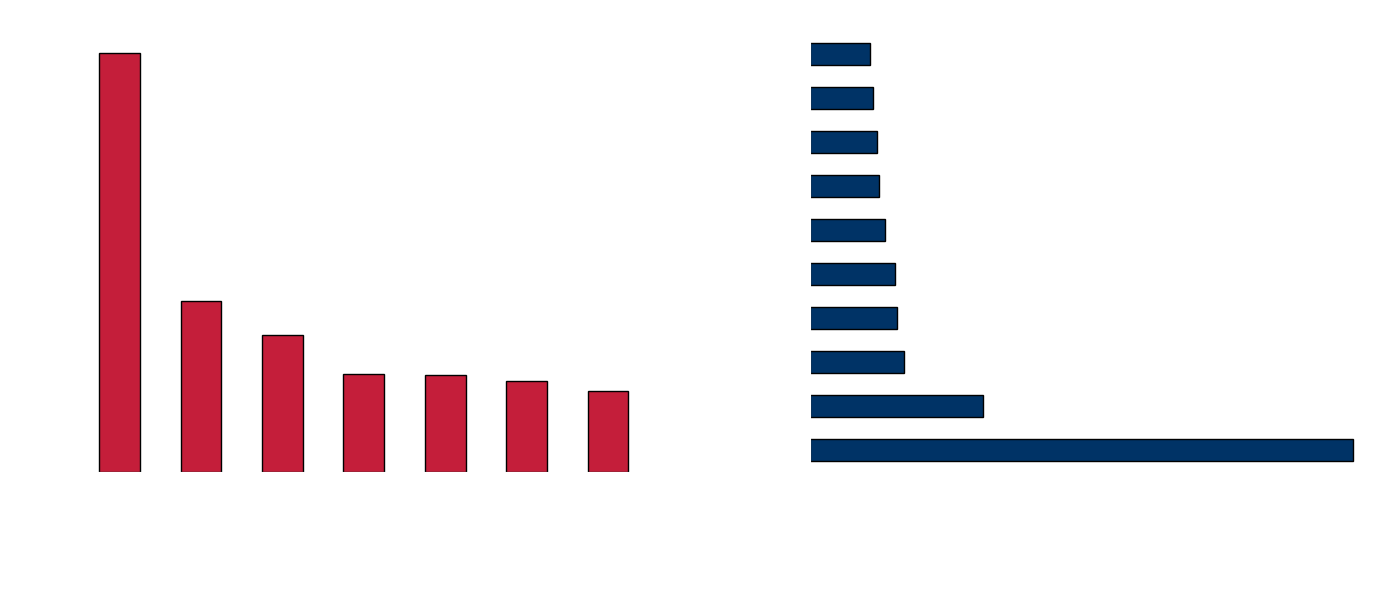

DISTRIBUCIÓN GEOGRÁFICA
Provincia
SAN JOSE      54589
ALAJUELA      22337
PUNTARENAS    17940
GUANACASTE    12755
LIMON         12672
HEREDIA       11853
CARTAGO       10617
Name: count, dtype: int64

Total registros con provincia válida: 142,763

Top 10 Cantones:
Canton
SAN JOSE         29741
ALAJUELA          9470
HEREDIA           5146
PUNTARENAS        4735
CARTAGO           4618
SAN CARLOS        4088
LIBERIA           3741
DESAMPARADOS      3648
LIMON             3406
PEREZ ZELEDON     3282
Name: count, dtype: int64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
axes[0].set_facecolor('white')
axes[1].set_facecolor('white')

provincias_filtradas = df[~df['Provincia'].isin(['Desconocido', 'Sin datos', 'DESCONOCIDO'])]

delitos_por_provincia = provincias_filtradas['Provincia'].value_counts()
delitos_por_provincia.plot(kind='bar', ax=axes[0], color='#C41E3A', edgecolor='black')
axes[0].set_title('Delitos por Provincia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Provincia', fontsize=12)
axes[0].set_ylabel('Número de Delitos', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

cantones_filtrados = df[~df['Canton'].isin(['Desconocido', 'Sin datos', 'DESCONOCIDO'])]

top_cantones = cantones_filtrados['Canton'].value_counts().head(10)
top_cantones.plot(kind='barh', ax=axes[1], color='#003366', edgecolor='black')
axes[1].set_title('Top 10 Cantones con Más Delitos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Delitos', fontsize=12)
axes[1].set_ylabel('Cantón', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


print("DISTRIBUCIÓN GEOGRÁFICA")
print(delitos_por_provincia)

print(f"\nTotal registros con provincia válida: {delitos_por_provincia.sum():,}")

print("\nTop 10 Cantones:")
print(top_cantones)


San José concentra la mayor cantidad de delitos con 54,955 incidentes, representando aproximadamente el 38% del total nacional. Le siguen Alajuela y Puntarenas.
Esto es lógico dado que San José es la provincia más poblada y el centro económico del país.

El cantón de San José encabeza la lista con 29,954 delitos, seguido por Alajuela. Esto confirma que la Gran Área Metropolitana (GAM) es la región con mayor incidencia delictiva.

### Análisis de Víctimas

---

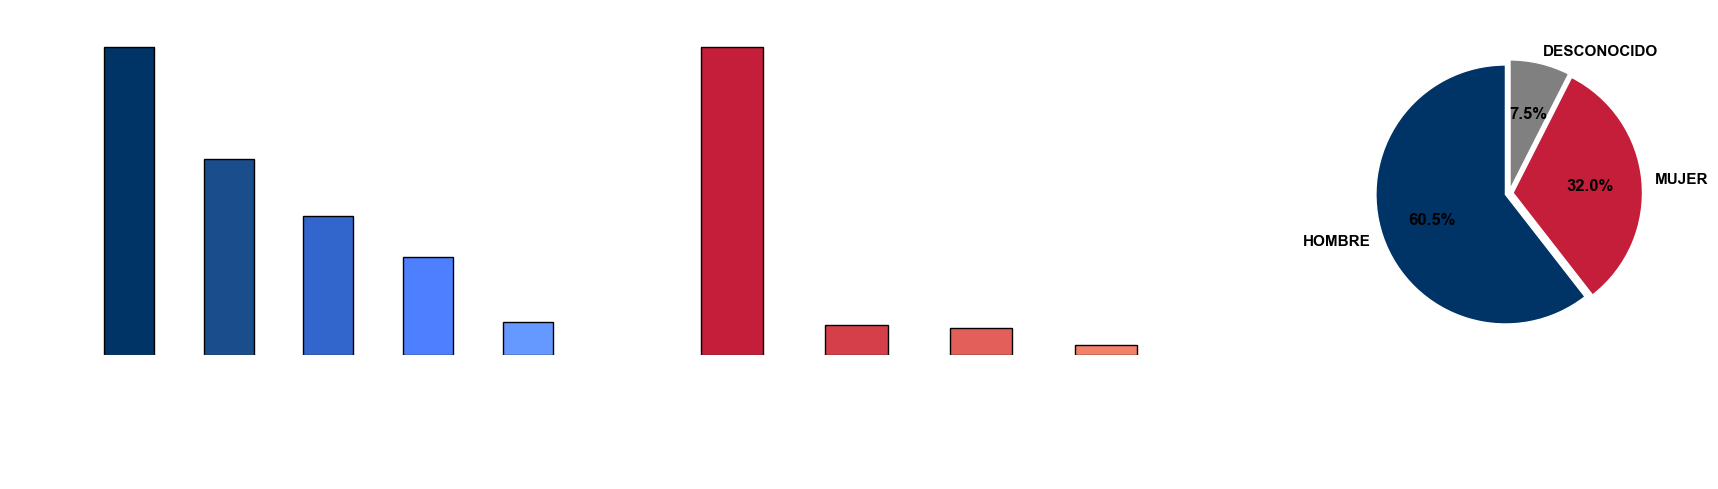

PERFIL DE VÍCTIMAS
Tipo de víctima más común: PERSONA (56,815 casos)
Edad más común: Mayor de edad (117,118 casos)
Sexo más común: HOMBRE (86,424 casos)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

axes[0].set_facecolor('white')
axes[1].set_facecolor('white')
axes[2].set_facecolor('white')


victimas = df['Victima'].value_counts()

colores_azules = ['#003366', '#1a4d8c', '#3366cc', '#4d7fff', '#6699ff']
victimas.plot(kind='bar', ax=axes[0], color=colores_azules[:len(victimas)], edgecolor='black')
axes[0].set_title('Tipo de Víctima', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo', fontsize=12)
axes[0].set_ylabel('Número', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

edades = df['Edad'].value_counts()

colores_rojos = ['#C41E3A', '#D43F4A', '#E35F5A', '#F2806A', '#FFA07A']
edades.plot(kind='bar', ax=axes[1], color=colores_rojos[:len(edades)], edgecolor='black')
axes[1].set_title('Edad de las Víctimas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Edad', fontsize=12)
axes[1].set_ylabel('Número', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

sexos = df['Sexo'].value_counts()


colores_pie = ['#003366', '#C41E3A', '#808080']

wedges, texts, autotexts = axes[2].pie(sexos,
                                        labels=sexos.index,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        colors=colores_pie,
                                        textprops={'fontsize': 11},
                                        explode=[0.03, 0.03, 0.03])

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

for text in texts:
    text.set_color('black')
    text.set_fontweight('bold')

axes[2].set_title('Sexo de las Víctimas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


print("PERFIL DE VÍCTIMAS")
print(f"Tipo de víctima más común: {victimas.index[0]} ({victimas.values[0]:,} casos)")
print(f"Edad más común: {edades.index[0]} ({edades.values[0]:,} casos)")
print(f"Sexo más común: {sexos.index[0]} ({sexos.values[0]:,} casos)")

La mayoría de las víctimas son personas naturales (PERSONA). Le siguen vehículos y viviendas.

Las víctimas mayores de edad son las más afectadas. Los menores de edad representan solo el 12%.

Los hombres son víctimas en 86,980 casos, mientras que las mujeres lo son en 52,211 casos (32%). Esta diferencia podría explicarse por la mayor exposición de los hombres en espacios públicos.

### Análisis Temporal (Meses y Años)

---

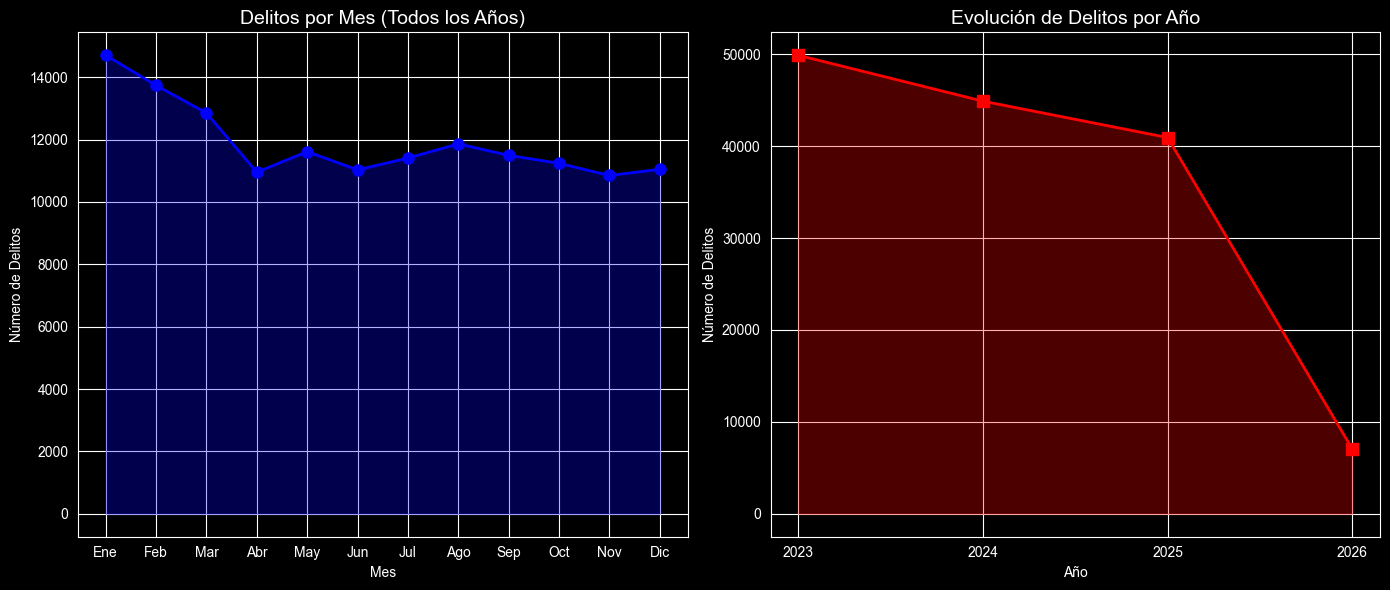

ESTADÍSTICAS TEMPORALES
Mes con más delitos: 1 (14,703 delitos)
Mes con menos delitos: 11 (10,848 delitos)
Año con más delitos: 2023 (49,893 delitos)


In [24]:
#Extraer mes y año
df['Mes'] = df['Fecha'].dt.month
df['Año'] = df['Fecha'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Gráfico 1: Delitos por mes (todos los años)
delitos_por_mes = df.groupby('Mes').size()
axes[0].plot(delitos_por_mes.index, delitos_por_mes.values,
             marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
axes[0].fill_between(delitos_por_mes.index, delitos_por_mes.values, alpha=0.3, color='blue')
axes[0].set_title('Delitos por Mes (Todos los Años)', fontsize=14)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Número de Delitos')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                          'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

#Gráfico 2: Evolución temporal por año
delitos_por_año = df.groupby('Año').size()
axes[1].plot(delitos_por_año.index, delitos_por_año.values,
             marker='s', linestyle='-', linewidth=2, markersize=8, color='red')
axes[1].fill_between(delitos_por_año.index, delitos_por_año.values, alpha=0.3, color='red')
axes[1].set_title('Evolución de Delitos por Año', fontsize=14)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de Delitos')
axes[1].set_xticks(delitos_por_año.index)

plt.tight_layout()
plt.show()


print("ESTADÍSTICAS TEMPORALES")
print(f"Mes con más delitos: {delitos_por_mes.idxmax()} ({delitos_por_mes.max():,} delitos)")
print(f"Mes con menos delitos: {delitos_por_mes.idxmin()} ({delitos_por_mes.min():,} delitos)")
print(f"Año con más delitos: {delitos_por_año.idxmax()} ({delitos_por_año.max():,} delitos)")

Los meses con mayor incidencia delictiva son enero, febrero y marzo.

Abril es el mes con menos delitos.

Posibles causas:

Períodos vacacionales

Cambios estacionales

Eventos económicos

### Serie Temporal (Tendencia Diaria)
---

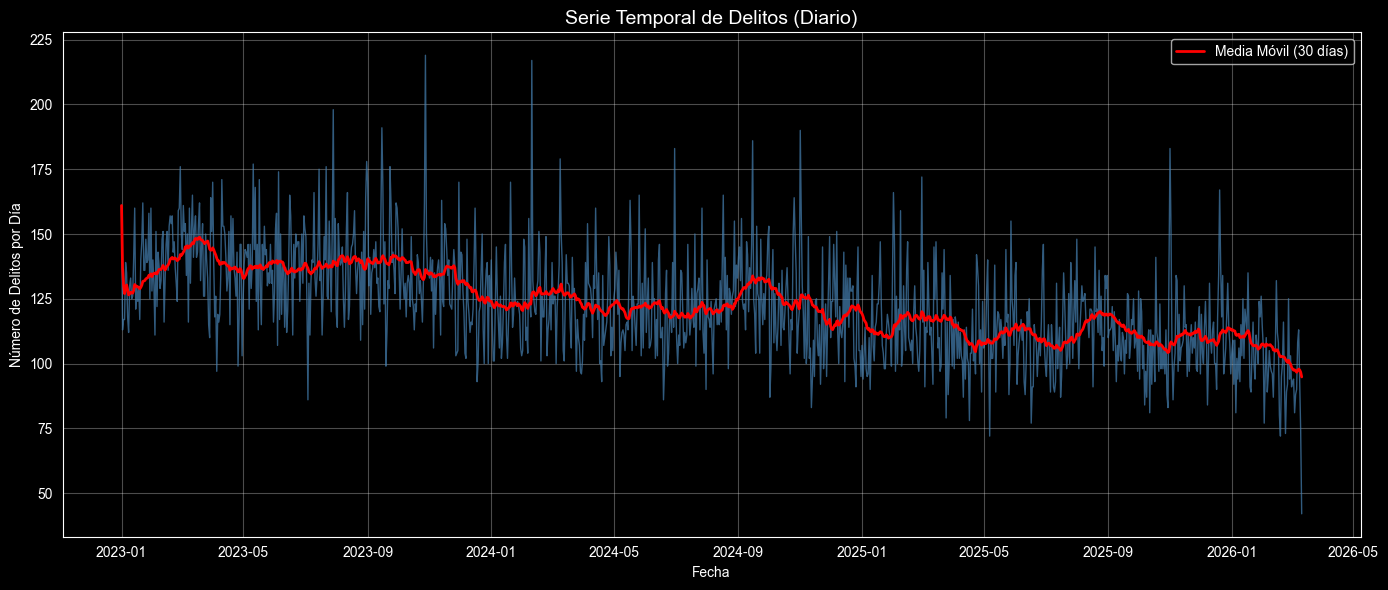

ESTADÍSTICAS DE LA SERIE TEMPORAL
Promedio de delitos por día: 122.5
Máximo de delitos en un día: 219
Mínimo de delitos en un día: 42


In [25]:
delitos_por_dia = df.groupby('Fecha').size()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(delitos_por_dia.index, delitos_por_dia.values,
        linewidth=1, alpha=0.7, color='steelblue')
ax.set_title('Serie Temporal de Delitos (Diario)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de Delitos por Día')

media_movil = delitos_por_dia.rolling(window=30, min_periods=1).mean()
ax.plot(media_movil.index, media_movil.values,
        linewidth=2, color='red', label='Media Móvil (30 días)')

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ESTADÍSTICAS DE LA SERIE TEMPORAL")
print(f"Promedio de delitos por día: {delitos_por_dia.mean():.1f}")
print(f"Máximo de delitos en un día: {delitos_por_dia.max():,}")
print(f"Mínimo de delitos en un día: {delitos_por_dia.min():,}")

Fin de año = Mayor actividad comercial, más personas en la calle

Aguinaldo =	Mayor circulación de dinero en diciembre

Vacaciones = Más oportunidades para delitos contra la propiedad

Rezago de denuncias = Delitos de diciembre se reportan en enero

Conclusiones

In [26]:
print(f"""
 RESULTADOS CLAVE:

1. VOLUMEN DE DATOS:
   - Total de registros: {len(df):,} incidentes
   - Cobertura: {df['Fecha'].nunique()} días de datos

2. DISTRIBUCIÓN DE DELITOS:
   - Delito más común: {top_delitos.index[0]} ({top_delitos.values[0]:,} incidentes)
   - Representa el {top_delitos.values[0]/len(df)*100:.1f}% del total

3. PATRONES TEMPORALES:
   - Hora pico: {delitos_por_hora.idxmax()} ({delitos_por_hora.max():,} incidentes en promedio por hora)
   - Mes con más incidentes: {delitos_por_mes.idxmax()} ({delitos_por_mes.max():,} incidentes)
   - Tendencia: {"Aumento" if delitos_por_año.iloc[-1] > delitos_por_año.iloc[0] else "Estable"}

4. DISTRIBUCIÓN GEOGRÁFICA:
   - Provincia con más delitos: {delitos_por_provincia.index[0]} ({delitos_por_provincia.values[0]:,} incidentes)
   - Cantón con más delitos: {top_cantones.index[0]} ({top_cantones.values[0]:,} incidentes)

5. PERFIL DE VÍCTIMAS:
   - Edad predominante: {edades.index[0]}
   - Sexo predominante: {sexos.index[0]}
""")


 RESULTADOS CLAVE:

1. VOLUMEN DE DATOS:
   - Total de registros: 142,781 incidentes
   - Cobertura: 1166 días de datos

2. DISTRIBUCIÓN DE DELITOS:
   - Delito más común: HURTO (47,269 incidentes)
   - Representa el 33.1% del total

3. PATRONES TEMPORALES:
   - Hora pico: 0 (28,024 incidentes en promedio por hora)
   - Mes con más incidentes: 1 (14,703 incidentes)
   - Tendencia: Estable

4. DISTRIBUCIÓN GEOGRÁFICA:
   - Provincia con más delitos: SAN JOSE (54,589 incidentes)
   - Cantón con más delitos: SAN JOSE (29,741 incidentes)

5. PERFIL DE VÍCTIMAS:
   - Edad predominante: Mayor de edad
   - Sexo predominante: HOMBRE



El análisis revela que los delitos contra la propiedad dominan la criminalidad en Costa Rica, siendo el hurto el delito más frecuente. Los patrones temporales muestran que la medianoche concentra la mayor actividad delictiva, seguida de una marcada estacionalidad donde enero es el mes con más reportes, posiblemente por el rezago de denuncias de diciembre. La tendencia general se mantiene estable durante el período analizado, sin incrementos o disminuciones significativas.

Geográficamente, la Gran Área Metropolitana concentra la criminalidad, con la provincia de San José como la de mayor incidencia y el cantón central como el de más alto registro. Las víctimas son predominantemente hombres adultos.